13524027 Aufa Rienaldifaza Ahmad (Kuis 1)

The goal of this problem is to estimate a camera's pose and orientation from a set of object points, their corresponding image projections, the camera's intrinsic matrix, and the distortion effects. 

The camera's pose and orientation is usually called the extrinsic matrix which is denoted by 
$$ 
T = \begin{bmatrix} R & t \end{bmatrix}. 
$$ 

A 2D coordinate of an object in the camera frame can be denoted as $(u, v)$ which resulted from the projection of the world coordinate system $X_w$ using the perspective projection model $(\Pi)$. 

$$
\begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = A \Pi^c T_w \begin{bmatrix} X_w \\ Y_w \\ Z_w \\ 1 \end{bmatrix}, \\ \text{where} \ 
\Pi = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \end{bmatrix} ...(1), 
$$
hence we have 
$$
\begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}
\begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \end{bmatrix} \begin{bmatrix} r_{11} & r_{12} & r_{13} & t_x \\ r_{21} & r_{22} & r_{23} & t_y \\ r_{31} & r_{32} & r_{33} & t_z \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} X_w \\ Y_w \\ Z_w \\ 1 \end{bmatrix} ... (2). 
$$

The estimated pose is the rotation and the translation vectors that allow transforming a 3D point expressed in the world frame into the camera frame: 

$$
\begin{bmatrix} X_c \\ Y_c \\ Z_c \\ 1 \end{bmatrix} = T_w \begin{bmatrix} X_w \\ Y_w \\ Z_w \\ 1 \end{bmatrix} ... (3)
$$

$$
\begin{bmatrix} X_c \\ Y_c \\ Z_c \\ 1 \end{bmatrix} =  \begin{bmatrix} r_{11} & r_{12} & r_{13} & t_x \\ r_{21} & r_{22} & r_{23} & t_y \\ r_{31} & r_{32} & r_{33} & t_z \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} X_w \\ Y_w \\ Z_w \\ 1 \end{bmatrix} ... (4)
$$



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print('OpenCV', cv2.__version__)

OpenCV 5.0.0


The first thing we have to do is to measure the dimensions of the object in real life. The dimensions of the object will be used for the $ 
\begin{bmatrix} X_w \\ Y_w \\ Z_w \\ 1 \end{bmatrix} $ in Equation 4.



Below is the object that is used, the dimensions are measured using a ruler. 


In [2]:
# dimensions of the rectangular object (planar, so Z_w = 0 for every corner)
L, W = 230, 160  # mm
T_ground_truth = 1080  

IMAGES = [f"converted/test_image_{n}.jpg" for n in (3, 4, 5)]
IMAGE = IMAGES[0]
IMAGE_WIDTH = 1600
# order: top-left, top-right, bottom-right, bottom-left
object_points = np.array([
    [0, 0, 0],
    [W, 0, 0],
    [W, L, 0],
    [0, L, 0],
], dtype=np.float64)

The next thing we need to do is to get the 2D coordinates of each corners in the image. This can be done by manually clicking the corners in the image. But for research purposes, we will be using contour detection which will extract the contour of the object and then approximate is polygon shape to four vertices. The block of code below shows the contour detection and the pixel of each corner. 

In [3]:
# open image
color_image = cv2.imread(IMAGE, -1)
assert color_image is not None, f"{IMAGE} not found"
scale = IMAGE_WIDTH / color_image.shape[1]  
color_image = cv2.resize(color_image, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

# grayscale image
grayscale_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

# the board is green 
hsv = cv2.cvtColor(color_image, cv2.COLOR_BGR2HSV)
thresh = cv2.inRange(hsv, (40, 80, 20), (90, 255, 200))
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

# detect contours 
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

## we assume that the largest contour is the object of interest
contour = max(contours, key=cv2.contourArea)

# approximate polygon
epsilon = 0.02 * cv2.arcLength(contour, True)
approx = cv2.approxPolyDP(contour, epsilon, True)
assert len(approx) == 4, f"expected 4 vertices, got {len(approx)}; adjust the threshold or epsilon"

# extract the coordinates
pts = approx.reshape(4, 2).astype(np.float32)

# order the corners: top-left, top-right, bottom-right, bottom-left
s = pts.sum(axis=1)
d = pts[:, 1] - pts[:, 0]
image_points = np.array([
    pts[np.argmin(s)],
    pts[np.argmin(d)],
    pts[np.argmax(s)],
    pts[np.argmax(d)],
], dtype=np.float32)

# refine the corners to sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.01)
image_points = cv2.cornerSubPix(
    grayscale_image, image_points.reshape(-1, 1, 2),
    winSize=(5, 5), zeroZone=(-1, -1), criteria=criteria
)

cv2.drawContours(color_image, [contour], -1, (0, 255, 0), 2)
for pt in image_points.reshape(-1, 2):
    cv2.circle(color_image, (int(pt[0]), int(pt[1])), 5, (0, 0, 255), -1)

## Camera calibration

`solvePnP` needs the camera matrix $A$ (the intrinsics $f_x, f_y, c_x, c_y$) and the lens distortion coefficients. They are found by calibrating on a checkerboard: the board's corners are at known positions in the board plane, so `cv2.calibrateCamera` can solve for the intrinsics from many views of it.

The calibration frames were extracted from a $1920 \times 1080$ video of a printed $10 \times 7$ checkerboard ($9 \times 6$ inner corners, $30$ mm squares) held at different tilts and positions. The cell below detects the corners in every frame, calibrates, drops frames whose own error is far above the median, and calibrates again. 

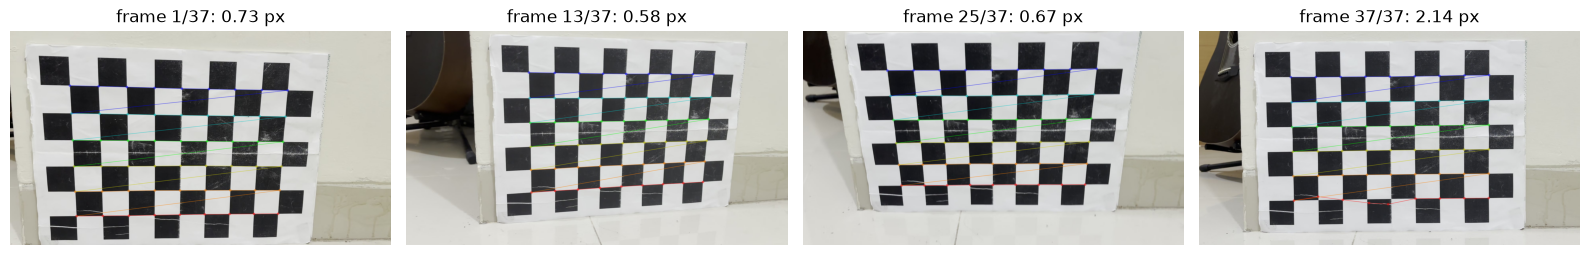

In [4]:
import glob

# calibration settings
COLS, ROWS, SQUARE = 9, 6, 30.0       
CAL_FRAMES = sorted(glob.glob("calib_mov/*.jpg"))
OUTLIER_FACTOR = 2.0                  
OUTLIER_MIN_ERROR_PX = 1.0            

INK, MUTED, WHITE = "black", "dimgray", "white"
BLUE, ORANGE, GREEN, RED = "tab:blue", "tab:orange", "tab:green", "tab:red"
NUM_SAMPLE_FRAMES = 4                 
CAL_FIGURE_SIZE = (16, 4)

board = np.zeros((ROWS * COLS, 3), np.float32)
board[:, :2] = np.mgrid[0:COLS, 0:ROWS].T.reshape(-1, 2) * SQUARE

cal_obj, cal_img, cal_files = [], [], []
for f in CAL_FRAMES:
    gray_frame = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    found, corners = cv2.findChessboardCornersSB(gray_frame, (COLS, ROWS),
                                                 cv2.CALIB_CB_EXHAUSTIVE | cv2.CALIB_CB_ACCURACY)
    if found:
        cal_obj.append(board); cal_img.append(corners); cal_files.append(f)
cal_size = gray_frame.shape[::-1]     

def calibrate_frames(obj, img):
    rms, K_, dist_, rvecs, tvecs = cv2.calibrateCamera(obj, img, cal_size, None, None)
    frame_errors = np.array([
        np.linalg.norm(cv2.projectPoints(o.astype(np.float64), r, t, K_, dist_)[0].reshape(-1, 2)
                       - i.reshape(-1, 2), axis=1).mean()
        for o, i, r, t in zip(obj, img, rvecs, tvecs)])
    return rms, K_, dist_, frame_errors

rms_first_pass, _, _, frame_errors = calibrate_frames(cal_obj, cal_img)
keep = frame_errors <= max(OUTLIER_FACTOR * np.median(frame_errors), OUTLIER_MIN_ERROR_PX)
rms, K_cal, dist_cal, _ = calibrate_frames([o for o, k in zip(cal_obj, keep) if k],
                                           [i for i, k in zip(cal_img, keep) if k])

sample_indices = np.linspace(0, len(cal_files) - 1, NUM_SAMPLE_FRAMES).astype(int)
fig, axes = plt.subplots(1, NUM_SAMPLE_FRAMES, figsize=CAL_FIGURE_SIZE)
for ax, idx in zip(axes, sample_indices):
    frame = cv2.imread(cal_files[idx])
    cv2.drawChessboardCorners(frame, (COLS, ROWS), cal_img[idx], True)
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.axis("off")
    ax.set_title(f"frame {idx + 1}/{len(cal_files)}: {frame_errors[idx]:.2f} px", color=INK)
plt.tight_layout()
plt.show()

Now, we have the $\begin{bmatrix} X_c \\ Y_c \\ Z_c \\ 1 \end{bmatrix} $ and $\begin{bmatrix} X_w \\ Y_w \\ Z_w \\ 1 \end{bmatrix} $, the remaining variables are the ones represented by $T_w$ in Equation 3.  

To solve the $T_w$ matrix, we will use OpenCV's method cv2.solvePnP().The details of OpenCV's implementation of PnP solver is explained at the end of this document.

In [5]:
# camera intrinsics
import json
from camera_intrinsics import intrinsics

h, w = color_image.shape[:2]
cam = json.load(open("camera_iphone15.json"))
if (cam["width"], cam["height"]) != (w, h):
    cam = intrinsics(26.0, w, h)
K = np.array([[cam["fx"], 0, cam["cx"]],
              [0, cam["fy"], cam["cy"]],
              [0, 0, 1]], dtype=np.float64)
dist = np.array(cam["dist"], dtype=np.float64)
print(K)

[[1.20185043e+03 0.00000000e+00 8.00000000e+02]
 [0.00000000e+00 1.20185043e+03 6.00000000e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


In [6]:
# call solvePnP method (IPPE is good for planar objects)
ok, rvec, tvec = cv2.solvePnP(object_points, image_points, K, dist, flags=cv2.SOLVEPNP_IPPE)
assert ok, "solvePnP failed"

# since the results of solvePnP isn't a matrix, convert
R, _ = cv2.Rodrigues(rvec)
T = np.hstack([R, tvec])
T_h = np.vstack([T, [0, 0, 0, 1]])
print("T_w =\n", np.round(T_h, 3))

proj, _ = cv2.projectPoints(object_points, rvec, tvec, K, dist)
print(f"reprojection error: {np.linalg.norm(proj.reshape(-1, 2) - image_points.reshape(-1, 2), axis=1).mean():.2f} px")
centre = (R @ np.array([W / 2, L / 2, 0.0]) + tvec.ravel())
print(f"distance to board centre: {np.linalg.norm(centre):.0f} mm (ground truth {T_ground_truth} mm)")
print(f"distance to TL corner (|t|): {np.linalg.norm(tvec):.0f} mm, Z_c of centre: {centre[2]:.0f} mm")

T_w =
 [[ 9.980000e-01 -1.200000e-02 -6.100000e-02 -4.892400e+01]
 [-2.000000e-03  9.750000e-01 -2.240000e-01 -2.466130e+02]
 [ 6.200000e-02  2.240000e-01  9.730000e-01  1.077071e+03]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]
reprojection error: 0.73 px
distance to board centre: 1116 mm (ground truth 1080 mm)
distance to TL corner (|t|): 1106 mm, Z_c of centre: 1108 mm


## Results for each picture

The function below runs the whole process for one photo (colour segmentation, corner extraction and ordering, `solvePnP`, the transformation $T_w$, reprojection and the comparison with the measured distance):

1. the photo, 2. the colour mask, 3. the contour and ordered corners, 4. the estimated object axes and the detected vs reprojected corners, 5. the board in the camera frame (3D)

Each of the next cells calls it for one photo.

In [7]:
from matplotlib.ticker import MaxNLocator

GREEN_HSV_LOW, GREEN_HSV_HIGH = (40, 80, 20), (90, 255, 200)  
MASK_CLEANUP_KERNEL = np.ones((5, 5), np.uint8)               
POLYGON_TOLERANCE = 0.02            
SUBPIXEL_WINDOW = (5, 5)
SUBPIXEL_CRITERIA = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.01)
EQUIVALENT_FOCAL_MM = 26.0          

FIGURE_SIZE = (17, 9)
TITLE_SIZE = 14
LABEL_SIZE = 11
SMALL_LABEL_SIZE = 9
ZOOM_MARGIN_PX = 50                 
FRAME_AXES_LENGTH_MM = 100          
SCENE_AXES_LENGTH_MM = 120          
CONTOUR_LINE_WIDTH = 1.5
CORNER_MARKER_SIZE, CORNER_MARKER_EDGE = 8, 1.5
COMPARE_MARKER_SIZE, COMPARE_MARKER_EDGE = 10, 2
SCENE_LINE_WIDTH = 2
NUM_3D_TICKS = 3
VIEW_ELEVATION_DEG, VIEW_AZIMUTH_DEG = 20, -60
AXIS_COLORS = {"X": RED, "Y": GREEN, "Z": BLUE}


def detect_corners(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = cv2.inRange(cv2.cvtColor(img, cv2.COLOR_BGR2HSV), GREEN_HSV_LOW, GREEN_HSV_HIGH)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, MASK_CLEANUP_KERNEL)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea)
    polygon = cv2.approxPolyDP(contour, POLYGON_TOLERANCE * cv2.arcLength(contour, True), True)
    assert len(polygon) == 4, f"expected 4 vertices, got {len(polygon)}"

    # order the corners: top-left has the smallest x+y, bottom-right the largest,
    # top-right the smallest y-x, bottom-left the largest
    vertices = polygon.reshape(4, 2).astype(np.float32)
    x_plus_y = vertices.sum(axis=1)
    y_minus_x = vertices[:, 1] - vertices[:, 0]
    ordered = np.array([vertices[np.argmin(x_plus_y)], vertices[np.argmin(y_minus_x)],
                        vertices[np.argmax(x_plus_y)], vertices[np.argmax(y_minus_x)]], np.float32)
    corners = cv2.cornerSubPix(gray, ordered.reshape(-1, 1, 2), SUBPIXEL_WINDOW, (-1, -1),
                               SUBPIXEL_CRITERIA).reshape(-1, 2)
    return mask, contour, corners


def solve_pose(corners, width, height):
    cam_ = intrinsics(EQUIVALENT_FOCAL_MM, width, height)
    K_ = np.array([[cam_["fx"], 0, cam_["cx"]], [0, cam_["fy"], cam_["cy"]], [0, 0, 1]])
    _, rvec_, tvec_ = cv2.solvePnP(object_points, corners.reshape(-1, 1, 2), K_, np.zeros(5),
                                   flags=cv2.SOLVEPNP_IPPE)
    R_, _ = cv2.Rodrigues(rvec_)
    T_ = np.vstack([np.hstack([R_, tvec_]), [0, 0, 0, 1]])
    return K_, rvec_, tvec_, T_


def label_box(ax, text, xy, offset, fontsize, **kwargs):
    ax.annotate(text, xy, xytext=offset, textcoords="offset points", color=WHITE, fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.2", fc=INK, ec="none"), **kwargs)


def to_scene_axes(points):
    points = np.atleast_2d(points)
    return points[:, 0], points[:, 2], -points[:, 1]


def show_pipeline(path, truth=T_ground_truth):
    img = cv2.imread(path)
    img = cv2.resize(img, None, fx=IMAGE_WIDTH / img.shape[1], fy=IMAGE_WIDTH / img.shape[1],
                     interpolation=cv2.INTER_AREA)
    height, width = img.shape[:2]
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask, contour, corners = detect_corners(img)
    K_, rvec_, tvec_, T_ = solve_pose(corners, width, height)
    R_ = T_[:3, :3]

    # reprojection error and distance
    reprojected, _ = cv2.projectPoints(object_points, rvec_, tvec_, K_, np.zeros(5))
    reprojected = reprojected.reshape(-1, 2)
    corner_errors = np.linalg.norm(reprojected - corners, axis=1)
    corners_cam = (R_ @ object_points.T + tvec_).T            
    centre_cam = corners_cam.mean(axis=0)
    distance = np.linalg.norm(centre_cam)
    tilt_deg = np.degrees(np.arccos(R_[2, 2]))

    x_min, y_min = corners.min(axis=0) - ZOOM_MARGIN_PX
    x_max, y_max = corners.max(axis=0) + ZOOM_MARGIN_PX

    fig = plt.figure(figsize=FIGURE_SIZE)
    grid = fig.add_gridspec(2, 3)

    # 1. photo
    ax = fig.add_subplot(grid[0, 0])
    ax.imshow(rgb); ax.axis("off")
    ax.set_title(f"1. Photo ({width}x{height})", color=INK)

    # colour mask
    ax = fig.add_subplot(grid[0, 1])
    ax.imshow(mask, cmap="gray"); ax.axis("off")
    ax.set_title("2. Colour mask (HSV)", color=INK)

    # contour and ordered corners
    ax = fig.add_subplot(grid[0, 2])
    ax.imshow(rgb); ax.axis("off")
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_max, y_min)
    closed_contour = np.vstack([contour.reshape(-1, 2), contour.reshape(-1, 2)[:1]])
    ax.plot(*closed_contour.T, color=GREEN, lw=CONTOUR_LINE_WIDTH)
    for number, (x, y) in enumerate(corners, start=1):
        ax.plot(x, y, "o", ms=CORNER_MARKER_SIZE, mfc=ORANGE, mec=WHITE, mew=CORNER_MARKER_EDGE)
        label_box(ax, str(number), (x, y), (8, -8), LABEL_SIZE, fontweight="bold")
    ax.set_title("3. Contour and corners (1 TL, 2 TR, 3 BR, 4 BL)", color=INK)

    # estimated axes, detected vs reprojected corners
    ax = fig.add_subplot(grid[1, 0])
    photo_with_axes = rgb.copy()
    cv2.drawFrameAxes(photo_with_axes, K_, np.zeros(5), rvec_, tvec_, FRAME_AXES_LENGTH_MM)  # X red, Y green, Z blue
    ax.imshow(photo_with_axes); ax.axis("off")
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_max, y_min)
    ax.plot(*corners.T, "o", ms=COMPARE_MARKER_SIZE, mfc="none", mec=BLUE, mew=COMPARE_MARKER_EDGE, label="detected")
    ax.plot(*reprojected.T, "x", ms=COMPARE_MARKER_SIZE, mec=ORANGE, mew=COMPARE_MARKER_EDGE, label="reprojected")
    for corner, error in zip(corners, corner_errors):
        label_box(ax, f"{error:.2f} px", corner, (6, 6), SMALL_LABEL_SIZE)
    ax.legend(loc="lower center", frameon=False, ncol=2, labelcolor=WHITE)
    ax.set_title("4. Estimated axes, detected vs reprojected corners", color=INK)

    # board in the camera frame (T_w applied)
    ax = fig.add_subplot(grid[1, 1], projection="3d")
    origin = np.zeros(3)
    for axis_name, unit_vector in zip("XYZ", np.eye(3)):
        axis_end = unit_vector * SCENE_AXES_LENGTH_MM
        ax.plot(*to_scene_axes(np.vstack([origin, axis_end])), color=AXIS_COLORS[axis_name], lw=SCENE_LINE_WIDTH)
        ax.text(*(c[0] for c in to_scene_axes(axis_end * 1.1)), axis_name, color=INK)
    board_outline = np.vstack([corners_cam, corners_cam[:1]])
    ax.plot(*to_scene_axes(board_outline), color=BLUE, lw=SCENE_LINE_WIDTH)
    ax.plot(*to_scene_axes(np.vstack([origin, centre_cam])), color=MUTED, lw=1, ls="--")
    ax.scatter(*to_scene_axes(origin), color=INK, s=30)
    ax.set_xlabel("X (right), mm", labelpad=8)
    ax.set_ylabel("Z (depth), mm", labelpad=8)
    ax.set_zlabel("-Y (up), mm", labelpad=6)
    for axis_3d in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis_3d.set_major_locator(MaxNLocator(NUM_3D_TICKS))
    extent = np.ptp(np.vstack([origin, board_outline]), axis=0)   # real proportions of the scene (X, Y, Z)
    ax.set_box_aspect((extent[0], extent[2], extent[1]))
    ax.view_init(elev=VIEW_ELEVATION_DEG, azim=VIEW_AZIMUTH_DEG)
    ax.set_title("5. Board in the camera frame (T_w applied)", color=INK)

    fig.suptitle(path, color=INK, fontsize=TITLE_SIZE)
    plt.tight_layout()
    plt.show()

    print("T_w =\n", np.round(T_, 3))
    print(f"reprojection error {corner_errors.mean():.2f} px | distance to board centre {distance:.0f} mm "
          f"(measured {truth:.0f} mm) | tilt {tilt_deg:.1f} deg")
    return dict(reproj=corner_errors.mean(), distance=distance, depth=centre_cam[2],
                tilt=tilt_deg, T=T_, pts=corners, K=K_)

### `test_image_3`

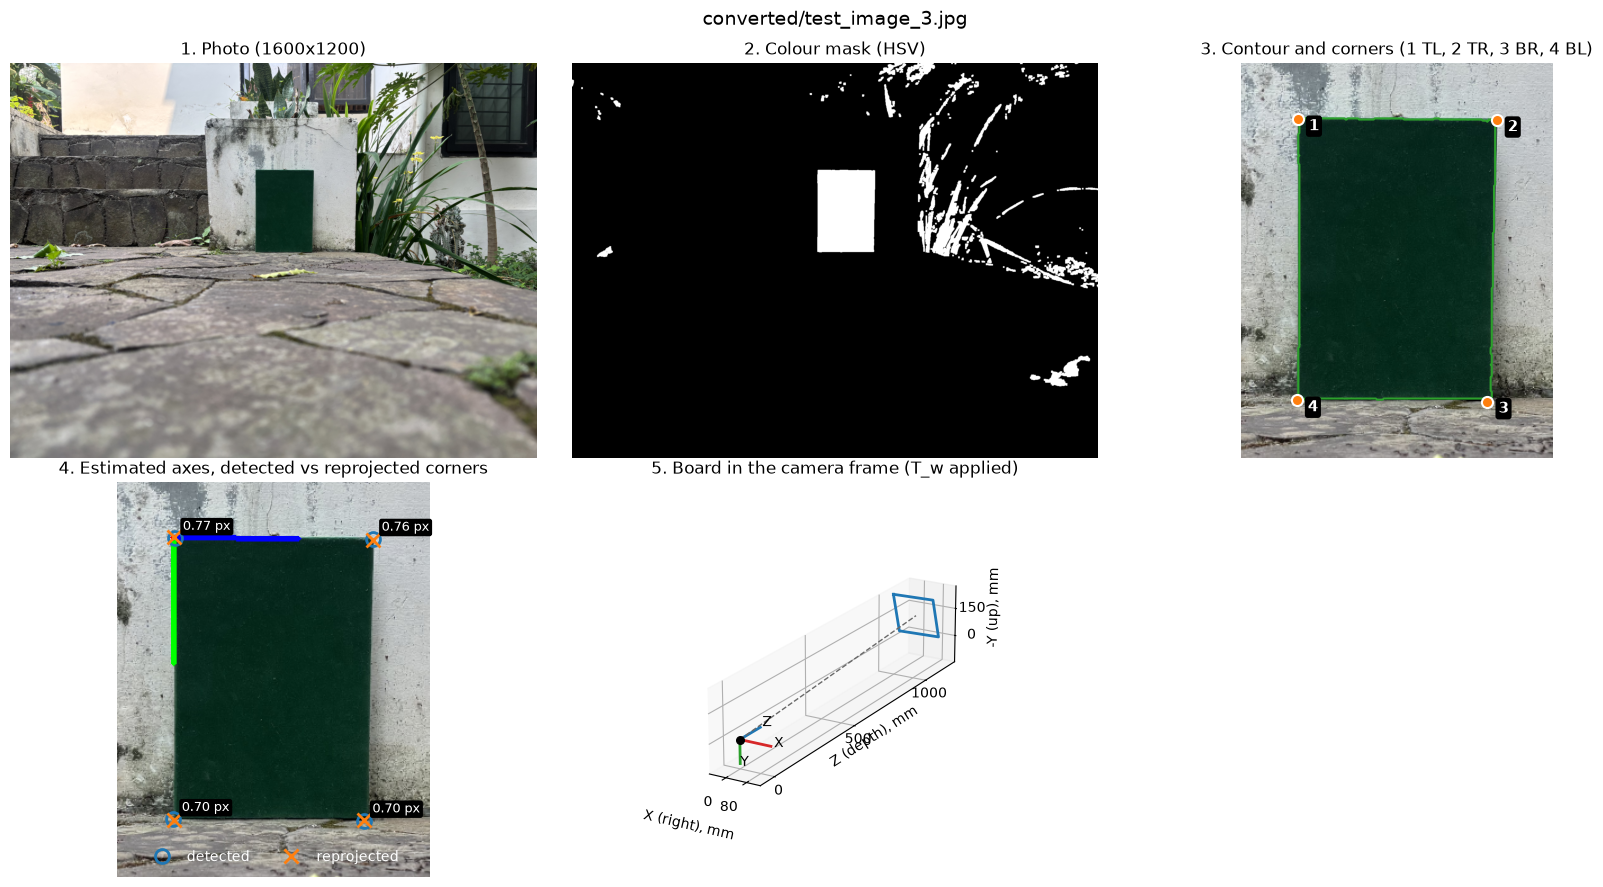

T_w =
 [[ 9.980000e-01 -1.200000e-02 -6.100000e-02 -4.892400e+01]
 [-2.000000e-03  9.750000e-01 -2.240000e-01 -2.466130e+02]
 [ 6.200000e-02  2.240000e-01  9.730000e-01  1.077071e+03]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]
reprojection error 0.73 px | distance to board centre 1116 mm (measured 1080 mm) | tilt 13.4 deg


In [8]:
res_3 = show_pipeline(IMAGES[0])

### `test_image_4`

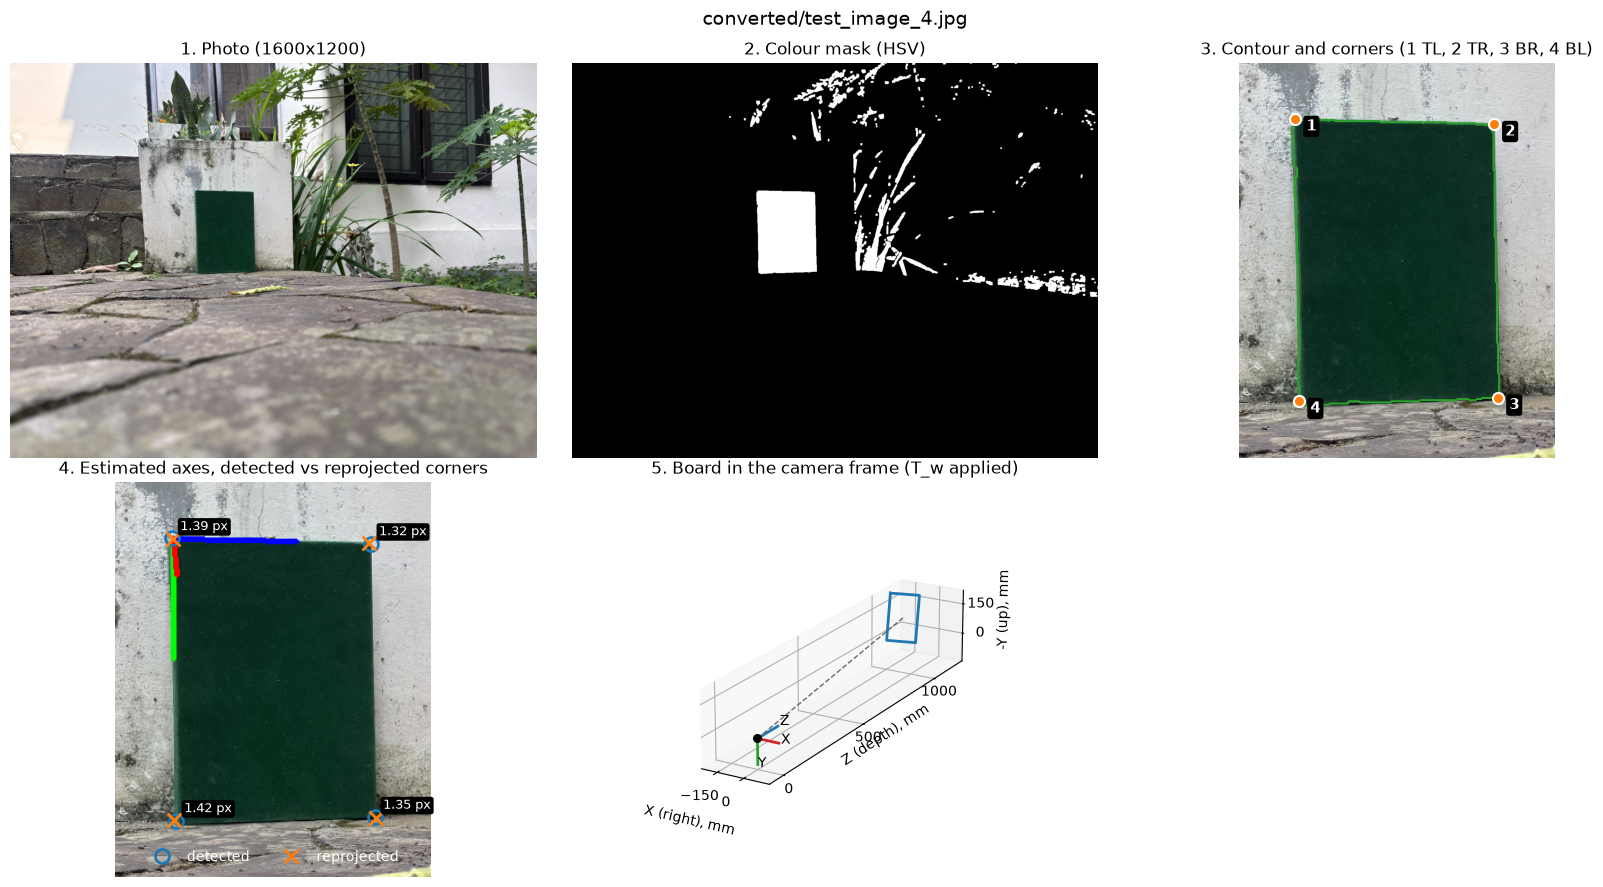

T_w =
 [[ 9.860000e-01  3.200000e-02 -1.610000e-01 -2.159710e+02]
 [-8.000000e-03  9.890000e-01  1.490000e-01 -1.948390e+02]
 [ 1.640000e-01 -1.460000e-01  9.760000e-01  1.103425e+03]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]
reprojection error 1.37 px | distance to board centre 1111 mm (measured 1080 mm) | tilt 12.7 deg


In [9]:
res_4 = show_pipeline(IMAGES[1])

### `test_image_5`

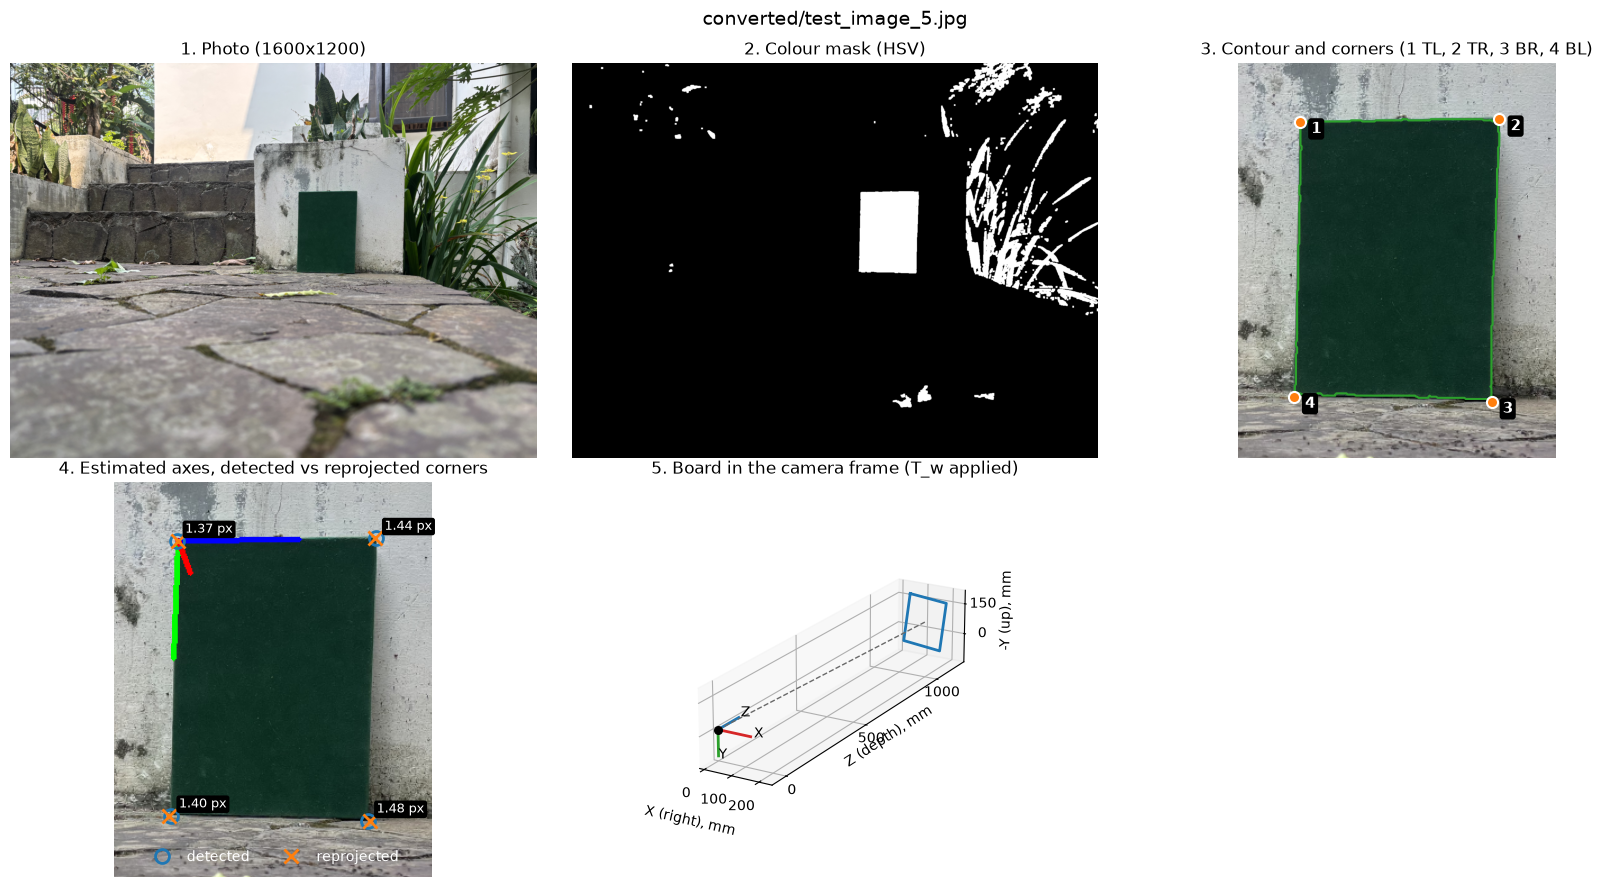

T_w =
 [[ 9.830000e-01 -4.000000e-02  1.790000e-01  7.299900e+01]
 [ 1.900000e-02  9.920000e-01  1.220000e-01 -1.944780e+02]
 [-1.820000e-01 -1.170000e-01  9.760000e-01  1.124389e+03]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]
reprojection error 1.42 px | distance to board centre 1109 mm (measured 1080 mm) | tilt 12.5 deg


In [10]:
res_5 = show_pipeline(IMAGES[2])

### Summary

In [11]:
results = {p: r for p, r in zip(IMAGES, (res_3, res_4, res_5))}
print(f"{'image':<30}{'reproj [px]':>12}{'distance [mm]':>15}{'depth [mm]':>12}{'tilt [deg]':>12}{'error [%]':>11}")
for p, r in results.items():
    print(f"{p:<30}{r['reproj']:>12.2f}{r['distance']:>15.0f}{r['depth']:>12.0f}{r['tilt']:>12.1f}"
          f"{(r['distance'] / T_ground_truth - 1) * 100:>+11.1f}")
d = np.array([r["distance"] for r in results.values()])
print(f"\nmean distance {d.mean():.0f} mm (std {d.std():.1f} mm) vs ground truth {T_ground_truth} mm")

image                          reproj [px]  distance [mm]  depth [mm]  tilt [deg]  error [%]
converted/test_image_3.jpg            0.73           1116        1108        13.4       +3.4
converted/test_image_4.jpg            1.37           1111        1100        12.7       +2.9
converted/test_image_5.jpg            1.42           1109        1096        12.5       +2.7

mean distance 1112 mm (std 3.1 mm) vs ground truth 1080 mm


### Camera orientation and pose

$T_w = [R \mid t]$ maps board coordinates into the camera frame, so it describes the *board as seen from the camera*. The camera's own orientation and position in the board frame follow from it:

- Orientation,$R_{cam} = R^\top$. 
- Position,  the camera centre $C = -R^\top t$.

The board frame has its origin at the top-left corner, $X$ along the top edge (right), $Y$ along the side edge (down) and $Z = X \times Y$, pointing into the board. A camera in front of the board therefore has $Z < 0$.

For a planar target with four points, `solvePnP` (IPPE) returns two solutions that fit the corners almost equally well and differ mainly in the sign of the tilt. The cell lists both. The first is the one with the lowest reprojection error, which is what `solvePnP` returns.

In [12]:
def camera_pose(R_, t_):
    euler = cv2.RQDecomp3x3(R_)[0]            
    C = -R_.T @ t_.ravel()                    
    axis = R_.T @ np.array([0.0, 0.0, 1.0])   
    return euler, C, axis

for path, r in results.items():
    R_, t_ = r["T"][:3, :3], r["T"][:3, 3]
    euler, C, axis = camera_pose(R_, t_)
    print(path)
    print(f"  reproj {r['reproj']:.2f} px | "
          f"rotation X,Y,Z = {np.round(euler, 1)} deg | camera centre = {np.round(C)} mm | "
          f"optical axis = {np.round(axis, 3)}")

converted/test_image_3.jpg
  reproj 0.73 px | rotation X,Y,Z = [13.  -3.5 -0.1] deg | camera centre = [-1.800e+01 -1.000e+00 -1.106e+03] mm | optical axis = [0.062 0.224 0.973]
converted/test_image_4.jpg
  reproj 1.37 px | rotation X,Y,Z = [-8.5 -9.5 -0.4] deg | camera centre = [   30.   360. -1082.] mm | optical axis = [ 0.164 -0.146  0.976]
converted/test_image_5.jpg
  reproj 1.42 px | rotation X,Y,Z = [-6.8 10.5  1.1] deg | camera centre = [  137.   327. -1087.] mm | optical axis = [-0.182 -0.117  0.976]


## Result Analysis

### Frames
The board frame has its origin at the top-left corner of the board, $X$ along the top edge (to the right), $Y$ along the side edge (down) and $Z = X \times Y$ (into the board). The camera frame follows the OpenCV convention: $X_c$ right, $Y_c$ down, $Z_c$ along the optical axis. All lengths are in mm.

### Extrinsic Matrix
$T_w$ maps board coordinates into the camera frame (Equations 3 and 4). For `test_image_3`:

$$
T_w = \begin{bmatrix} 0.998 & -0.012 & -0.061 & -48.9 \\ -0.002 & 0.975 & -0.224 & -246.6 \\ 0.062 & 0.224 & 0.973 & 1077.1 \\ 0 & 0 & 0 & 1 \end{bmatrix}
$$

### Camera Orientation
The camera orientation in the board frame is $R_{cam} = R^\top$ ($R$ is the rotation block of $T_w$). Writing $R = R_z R_y R_x$, the angles about the $X$, $Y$, $Z$ axes are $13.0^\circ$, $-3.5^\circ$ and $-0.1^\circ$ for `test_image_3` (rotation vector magnitude $13.4^\circ$). The optical axis in the board frame is $(0.062,\ 0.224,\ 0.973)$: the camera looks almost perpendicular to the board, $13.4^\circ$ from its normal, pitched about $13^\circ$ downward (the board $Y$ axis points down) and $3.6^\circ$ to the right, with essentially no roll ($-0.1^\circ$).

### Camera Position
The camera centre is $C = -R^\top t$. For `test_image_3`, $C = (-18,\ -1,\ -1106)$ mm in the board frame: $Z = -1106$ mm means it is $1106$ mm in front of the board plane, $98$ mm to the left of the board centre and $116$ mm above it (level with the top edge). The distance from the camera to the board centre is $1116$ mm.

The same for all three photos (the lowest-error solution of `solvePnP`):

| Image | Rotation about X, Y, Z [°] | Optical axis direction | Camera centre in board frame [mm] | Distance to board centre [mm] | Tilt from board normal |
|---|---|---|---|---|---|
| `test_image_3` | 13.0, −3.5, −0.1 | 13° down, 3.6° right | (−18, −1, −1106) | 1116 | 13.4° |
| `test_image_4` | −8.5, −9.5, −0.4 | 8.5° up, 9.5° right | (30, 360, −1082) | 1111 | 12.7° |
| `test_image_5` | −6.8, 10.5, 1.1 | 6.8° up, 10.6° left | (137, 327, −1087) | 1109 | 12.5° |

In all three the roll is below $1.1^\circ$, the camera is about $1.1$ m in front of the board, and the optical axis is within $13^\circ$ of the board normal. The yaw changes sign between photos ($-3.5^\circ$, $-9.5^\circ$, $+10.5^\circ$): the camera was moved sideways and rotated between shots.

### Reprojection error and distance
The corners projected by the estimated pose land $0.73$–$1.42$ px from the detected corners. The measured camera-to-board distance is $1080$ mm (iPhone Measure app), and the estimated distances to the board centre are:

| Image | Reprojection error [px] | Distance [mm] | Depth [mm] | Error vs 1080 mm |
|---|---|---|---|---|
| `test_image_3` | 0.73 | 1116 | 1108 | +3.4 % |
| `test_image_4` | 1.37 | 1111 | 1100 | +2.9 % |
| `test_image_5` | 1.42 | 1109 | 1096 | +2.7 % |

## Source of Error

The sensitivity of the estimated distance (`test_image_3`, baseline $1116$ mm) to each input was measured by perturbing it and re-running `solvePnP`:

| Source | Perturbation | Effect on distance |
|---|---|---|
| Focal length (intrinsics) | $\pm 2\%$ / $\pm 4\%$ | $\pm 22$ / $\pm 44$ mm |
| Corner detection noise | $1$ px random noise on each corner | $\pm 5$ mm (std) |
| Object dimensions | $L$ and $W$ both $+2$ mm / $+5$ mm | $+12$ / $+28$ mm |

1. The process of getting the intrinsic camera parameters, i.e. the camera calibration, is likely the main cause. The distance is almost proportional to the focal length in pixels. The HEIC photos are in photo mode, so the video calibration could not be used (it is valid only for the video's crop and resolution). 
2. The corners come from approximating a colour-mask contour with a polygon and refining with `cornerSubPix`. One pixel of random noise changes the distance by about $5$ mm, which is small. A better method might be just through getting the pixels manually from the image. 
3. Distortion was assumed to be zero. The board is near the centre of the image, where distortion is small, so this contributes little here.

# Conclusion
The reprojection error is about one pixel and the three photos agree to within $7$ mm, so detection and the solver are consistent. The remaining $+3\%$ ($\approx 30$ mm) over the measured distance is within the uncertainty of the estimated focal length ($\pm 2$ % gives $\pm 22$ mm) and the ground-truth measurement, so no single error source is dominant. A direct calibration in photo mode would reduce the focal-length uncertainty, and a larger tilt would better condition the pose.

# Appendix
## A bit more on PnP

### The problem
Perspective-n-Point (PnP) asks for the pose $(R, t)$ of a calibrated camera, given $n$ points $X_i$ known in the object (world) frame and their image projections $u_i = (u_i, v_i)$. With the camera matrix $A$ (called `K` in the code) and the model of Equation (2), the pose is the one that makes the projected points agree with the measured ones:

$$
\min_{R,\,t} \; \sum_{i=1}^{n} \left\lVert u_i - \pi\!\left(A\,(R X_i + t)\right) \right\rVert^2, \qquad \pi\!\left([x, y, z]^\top\right) = \left[\tfrac{x}{z}, \tfrac{y}{z}\right]^\top
$$

 The division by $z$ makes the problem non-linear, and $R$ has to stay a rotation matrix, so the unknowns are only 6 numbers (3 for rotation, 3 for translation). Each point gives 2 equations, so $n = 3$ is the minimum (and gives up to four solutions), and four or more points are used in practice.

### The planar case (our rectangle)
All four corners lie on the plane $Z_w = 0$, so the third column of $R$ drops out of Equation (2):

$$
s \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = A \begin{bmatrix} r_1 & r_2 & t \end{bmatrix} \begin{bmatrix} X_w \\ Y_w \\ 1 \end{bmatrix} = H \begin{bmatrix} X_w \\ Y_w \\ 1 \end{bmatrix}
$$

$H = A\,[\,r_1\ r_2\ t\,]$ is a $3 \times 3$ homography between the board plane and the image. It can be estimated linearly (the direct linear transform, DLT) from four point correspondences. Then $A^{-1}H = \lambda\,[\,r_1\ r_2\ t\,]$, where $\lambda$ makes $r_1$ and $r_2$ unit vectors, and the third axis is $r_3 = r_1 \times r_2$. Because of noise, the resulting matrix is not exactly a rotation, so it is replaced by the nearest one with an SVD. 

### How OpenCV does it
`cv2.solvePnP(objectPoints, imagePoints, cameraMatrix, distCoeffs, flags=...)` first removes the lens distortion from the image points using `distCoeffs`, and then runs the chosen solver. The solver is selected with `flags`:

| Flag | Idea |
|---|---|
| `SOLVEPNP_ITERATIVE` (default) | Initial pose from the DLT (or from the homography for planar points).
| `SOLVEPNP_EPNP` | Writes every point as a weighted sum of four virtual control points, solves a linear system for the control points in the camera frame, then refines the result.|
| `SOLVEPNP_P3P`, `SOLVEPNP_AP3P` | Minimal solvers that use exactly three points (a fourth one chooses between the candidate solutions). |
| `SOLVEPNP_IPPE` | estimates the homography and uses a first-order approximation of it around the point set to get the pose analytically (Collins and Bartoli). A planar target has a two-fold ambiguity, and OpenCV returns the solution with the lower reprojection error (`cv2.solvePnPGeneric` returns both). |
| `SOLVEPNP_IPPE_SQUARE` | The same as IPPE, for a square marker with a fixed corner order. |
| `SOLVEPNP_SQPNP` | A non-iterative solver that finds the global optimum of the reprojection-like cost. |

We used `SOLVEPNP_IPPE`, because the object is a flat rectangle. It requires the object points to be coplanar and listed in the same order as the image points, which is why the corners are sorted as top-left, top-right, bottom-right, bottom-left.

The result is returned as a rotation **vector** `rvec` and a translation vector `tvec`. The direction of `rvec` is the rotation axis and its length is the angle $\theta$ in radians. `cv2.Rodrigues` converts it to the rotation matrix with Rodrigues' formula.

### References
- OpenCV documentation: *Camera Calibration and 3D Reconstruction* (`solvePnP`, `solvePnPGeneric`, `Rodrigues`, `projectPoints`).